# Intel Image Classification: Data Exploration

This notebook verifies the Intel Image Classification dataset, summarizes the class balance, and inspects representative images. It intentionally does not train a model.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [2]:
# Resolve paths from the notebook location so the notebook works from the repository.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TRAIN_DIR = PROJECT_ROOT / "data" / "raw" / "intel" / "seg_train" / "seg_train"
TEST_DIR = PROJECT_ROOT / "data" / "raw" / "intel" / "seg_test" / "seg_test"

CLASS_NAMES = ["buildings", "forest", "glacier", "mountain", "sea", "street"]
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tif", ".tiff"}

print(f"Project root: {PROJECT_ROOT.resolve()}")
print(f"Training directory: {TRAIN_DIR.resolve()}")
print(f"Test directory: {TEST_DIR.resolve()}")

Project root: C:\Users\ArshadShaik\Desktop\image-classification-cnn
Training directory: C:\Users\ArshadShaik\Desktop\image-classification-cnn\data\raw\intel\seg_train\seg_train
Test directory: C:\Users\ArshadShaik\Desktop\image-classification-cnn\data\raw\intel\seg_test\seg_test


In [3]:
assert TRAIN_DIR.is_dir(), f"Training directory not found: {TRAIN_DIR}"
assert TEST_DIR.is_dir(), f"Test directory not found: {TEST_DIR}"

missing_train_classes = [name for name in CLASS_NAMES if not (TRAIN_DIR / name).is_dir()]
missing_test_classes = [name for name in CLASS_NAMES if not (TEST_DIR / name).is_dir()]
assert not missing_train_classes, f"Missing training classes: {missing_train_classes}"
assert not missing_test_classes, f"Missing test classes: {missing_test_classes}"

print("Dataset directories and all six class directories are present.")
print("Classes:", ", ".join(CLASS_NAMES))

Dataset directories and all six class directories are present.
Classes: buildings, forest, glacier, mountain, sea, street


In [4]:
def image_files(directory: Path) -> list[Path]:
    """Return image files directly inside a class directory in a stable order."""
    return sorted(
        path for path in directory.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )


def count_images(dataset_dir: Path) -> pd.Series:
    """Count supported image files for each expected class."""
    return pd.Series(
        {class_name: len(image_files(dataset_dir / class_name)) for class_name in CLASS_NAMES},
        name="image_count",
    )

train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)

counts_table = pd.DataFrame({"training": train_counts, "test": test_counts})
counts_table

,training,test
buildings,2191,437
forest,2271,474
glacier,2404,553
mountain,2512,525
sea,2274,510
street,2382,501


## Class distribution

The counts below are computed directly from the image files in each class directory.

In [5]:
print("Training images by class:")
for class_name, count in train_counts.items():
    print(f"  {class_name}: {count:,}")

print("\nTest images by class:")
for class_name, count in test_counts.items():
    print(f"  {class_name}: {count:,}")

print(f"\nTotal training images: {train_counts.sum():,}")
print(f"Total test images: {test_counts.sum():,}")

Training images by class:
  buildings: 2,191
  forest: 2,271
  glacier: 2,404
  mountain: 2,512
  sea: 2,274
  street: 2,382

Test images by class:
  buildings: 437
  forest: 474
  glacier: 553
  mountain: 525
  sea: 510
  street: 501

Total training images: 14,034
Total test images: 3,000


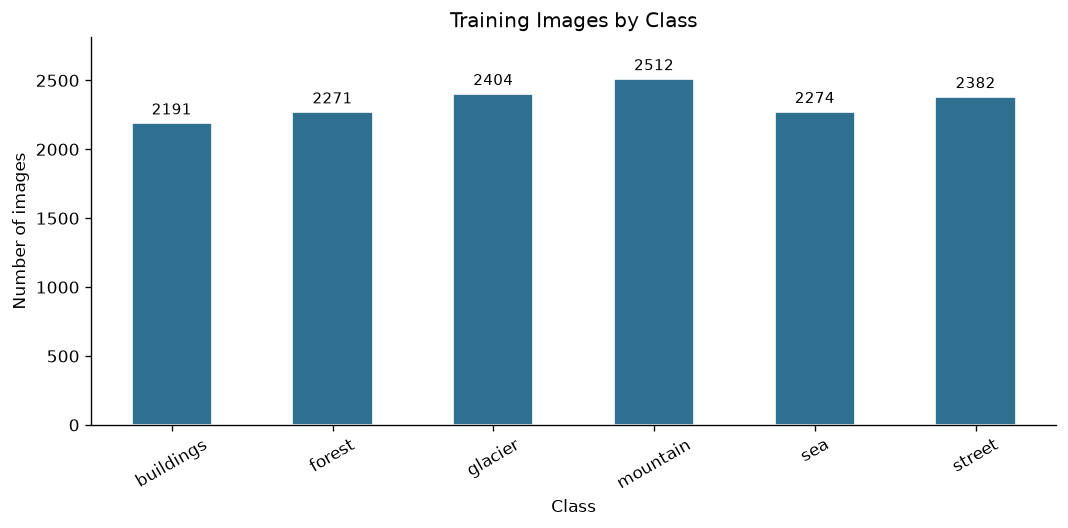

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
train_counts.plot(kind="bar", ax=ax, color="#2f6f8f", edgecolor="white")
ax.set_title("Training Images by Class")
ax.set_xlabel("Class")
ax.set_ylabel("Number of images")
ax.tick_params(axis="x", rotation=30)
ax.bar_label(ax.containers[0], fmt="%d", padding=3, fontsize=9)
ax.set_ylim(0, train_counts.max() * 1.12)
fig.tight_layout()
plt.show()

## Representative training images

One image is shown for each class to confirm the folder labels and image contents.

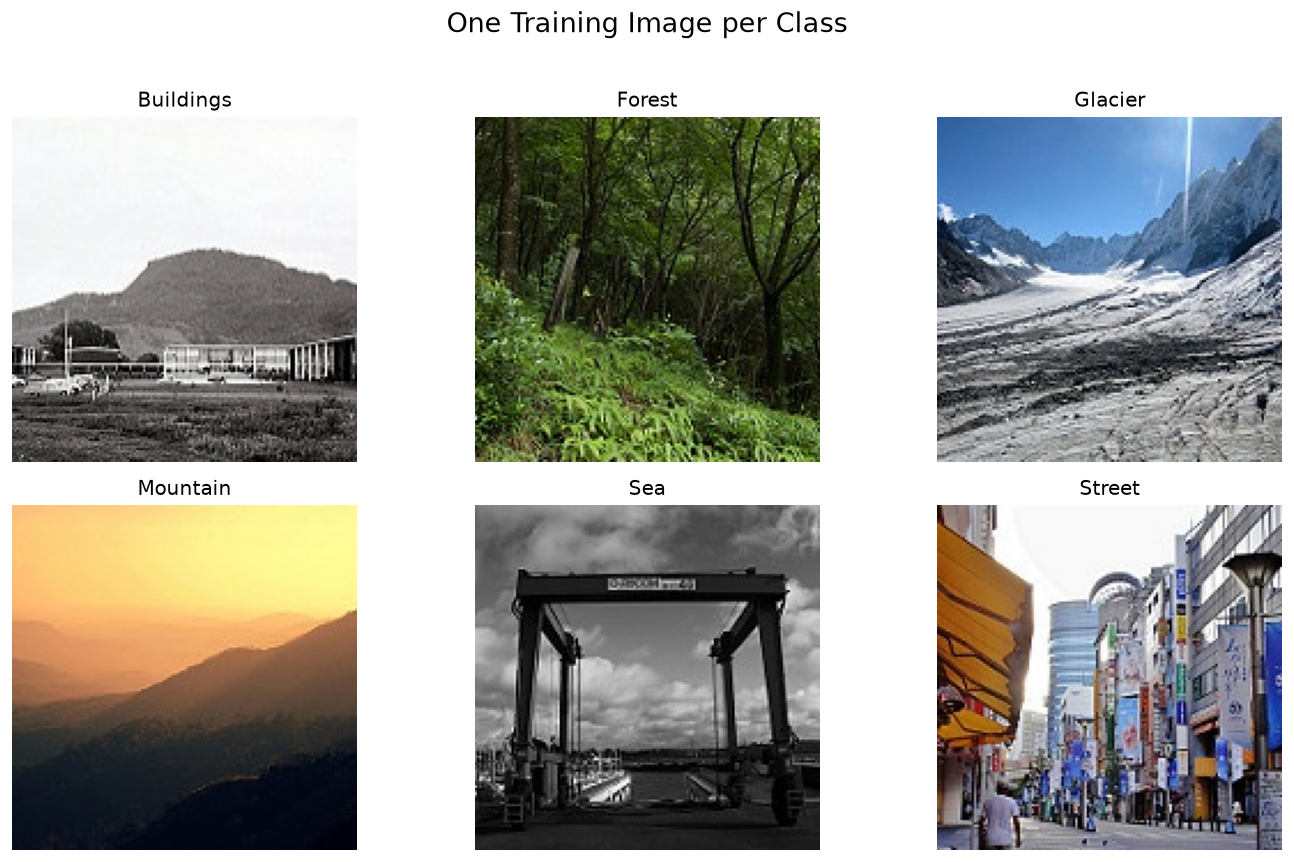

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for axis, class_name in zip(axes.flat, CLASS_NAMES):
    sample_path = image_files(TRAIN_DIR / class_name)[0]
    with Image.open(sample_path) as image:
        axis.imshow(image)
    axis.set_title(class_name.title())
    axis.axis("off")

fig.suptitle("One Training Image per Class", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

## Inspect an individual image

Path: C:\Users\ArshadShaik\Desktop\image-classification-cnn\data\raw\intel\seg_train\seg_train\buildings\0.jpg
Width: 150 pixels
Height: 150 pixels
Image mode: RGB
Number of channels: 3


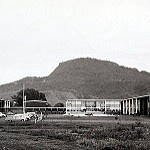

In [8]:
inspection_path = image_files(TRAIN_DIR / CLASS_NAMES[0])[0]

with Image.open(inspection_path) as inspection_image:
    width, height = inspection_image.size
    mode = inspection_image.mode
    channel_count = len(inspection_image.getbands())
    print(f"Path: {inspection_path.resolve()}")
    print(f"Width: {width} pixels")
    print(f"Height: {height} pixels")
    print(f"Image mode: {mode}")
    print(f"Number of channels: {channel_count}")
    display(inspection_image.copy())

## Observations

In [9]:
largest_training_class = train_counts.idxmax()
smallest_training_class = train_counts.idxmin()
train_balance_ratio = train_counts.max() / train_counts.min()

print(f"The training set contains {train_counts.sum():,} images across {len(CLASS_NAMES)} classes.")
print(f"The test set contains {test_counts.sum():,} images across the same {len(CLASS_NAMES)} classes.")
print(
    f"Training counts range from {train_counts.min():,} ({smallest_training_class}) "
    f"to {train_counts.max():,} ({largest_training_class}); "
    f"the largest class is {train_balance_ratio:.2f}x the smallest."
)
print("The class distribution is useful to check before training so evaluation metrics can be interpreted in context.")
print("Images may have different spatial dimensions, so a preprocessing pipeline should resize them consistently before batching.")
print("This notebook only explores and validates the data; it does not train a model.")

The training set contains 14,034 images across 6 classes.
The test set contains 3,000 images across the same 6 classes.
Training counts range from 2,191 (buildings) to 2,512 (mountain); the largest class is 1.15x the smallest.
The class distribution is useful to check before training so evaluation metrics can be interpreted in context.
Images may have different spatial dimensions, so a preprocessing pipeline should resize them consistently before batching.
This notebook only explores and validates the data; it does not train a model.
